In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


In [25]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

RAW_DATA_PATH = Path(path) / "raw-img"
PROJECT_DATA = Path("/content/data")
PROCESSED_DIR = PROJECT_DATA / "processed_images"

print(f"Correct Source path: {RAW_DATA_PATH}")
print(f"Classes found: {[d.name for d in RAW_DATA_PATH.iterdir() if d.is_dir()]}")

Correct Source path: /kaggle/input/animals10/raw-img
Classes found: ['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']


In [8]:
import os

os.makedirs("scripts", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("interfaces", exist_ok=True)
os.makedirs("weights", exist_ok=True)

print("Project structure created. Now upload your .py files to the corresponding folders.")

Project structure created. Now upload your .py files to the corresponding folders.


In [36]:
import shutil
import os
from pathlib import Path

if os.path.exists("/content/data"):
    shutil.rmtree("/content/data")

dataset_root = Path(path)
print(f"Dataset root: {dataset_root}")
for item in dataset_root.iterdir():
    print(f"  Found: {item.name}")

Dataset root: /kaggle/input/animals10
  Found: translate.py
  Found: raw-img


In [37]:
import random

translation_map = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider', 'scoiattolo': 'squirrel'
}

def split_dataset_final(source, output, train_p=0.7, val_p=0.15, test_p=0.15):
    src_path = Path(source).absolute()
    dst_path = Path(output).absolute()

    it_classes = [d.name for d in src_path.iterdir() if d.is_dir() and not d.name.startswith('.')]

    for it_cls in it_classes:
        en_cls = translation_map.get(it_cls, it_cls)

        files = []
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            files.extend(list((src_path / it_cls).glob(ext)))

        if not files:
            print(f"Warning: No images found in {src_path / it_cls}")
            continue

        random.shuffle(files)
        n = len(files)
        tr_idx = int(n * train_p)
        vl_idx = tr_idx + int(n * val_p)

        splits = {
            'train': files[:tr_idx],
            'val': files[tr_idx:vl_idx],
            'test': files[vl_idx:]
        }

        for split_name, split_files in splits.items():
            target_dir = dst_path / split_name / en_cls
            target_dir.mkdir(parents=True, exist_ok=True)
            for f in split_files:
                os.symlink(str(f.absolute()), str(target_dir / f.name))

    print(f"Success: Dataset split and translated at {dst_path}")

SOURCE_IMAGES = Path(path) / "raw-img"
split_dataset_final(SOURCE_IMAGES, "/content/data/processed_images")

Success: Dataset split and translated at /content/data/processed_images


In [38]:
import pandas as pd

def check_data(path):
    data = []
    base = Path(path)
    for split in ['train', 'val', 'test']:
        split_dir = base / split
        if split_dir.exists():
            for cls_dir in split_dir.iterdir():
                count = len(list(cls_dir.glob('*')))
                data.append({'Split': split, 'Class': cls_dir.name, 'Count': count})
    return pd.DataFrame(data)

df_check = check_data("/content/data/processed_images")
print("Unique classes found:", df_check['Class'].unique())
print(df_check.pivot_table(index='Class', columns='Split', values='Count', fill_value=0))

Unique classes found: ['chicken' 'squirrel' 'butterfly' 'cat' 'horse' 'sheep' 'elephant'
 'spider' 'dog' 'cow']
Split       test   train    val
Class                          
butterfly  318.0  1478.0  316.0
cat        251.0  1167.0  250.0
chicken    466.0  2168.0  464.0
cow        281.0  1306.0  279.0
dog        730.0  3404.0  729.0
elephant   218.0  1012.0  216.0
horse      394.0  1836.0  393.0
sheep      273.0  1274.0  273.0
spider     724.0  3374.0  723.0
squirrel   280.0  1303.0  279.0


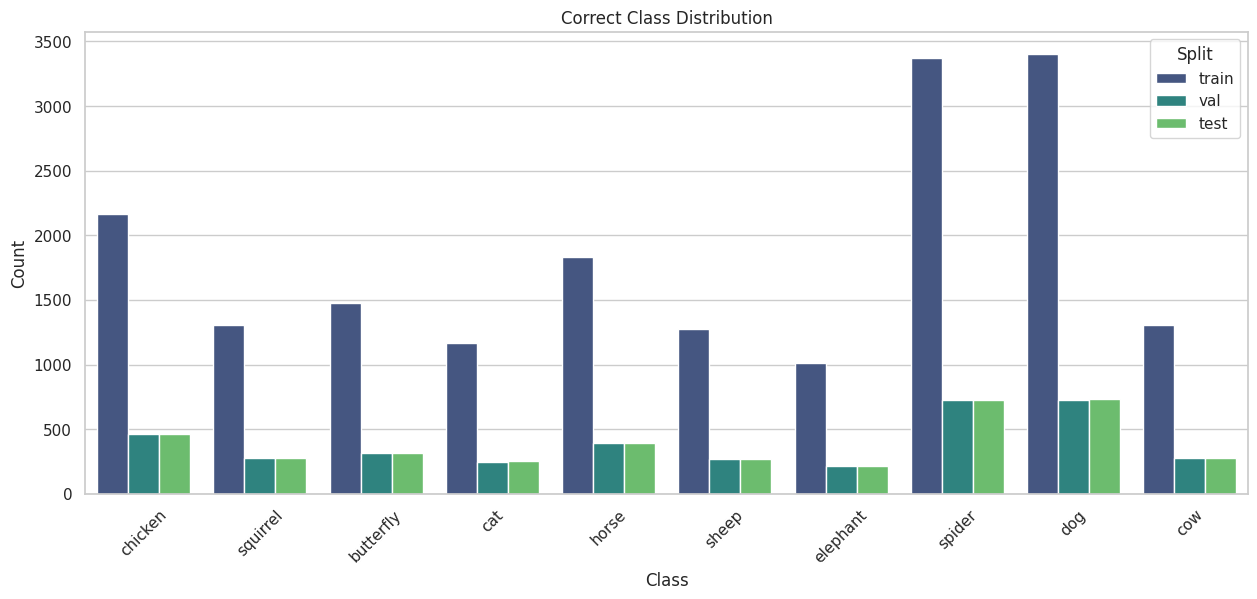

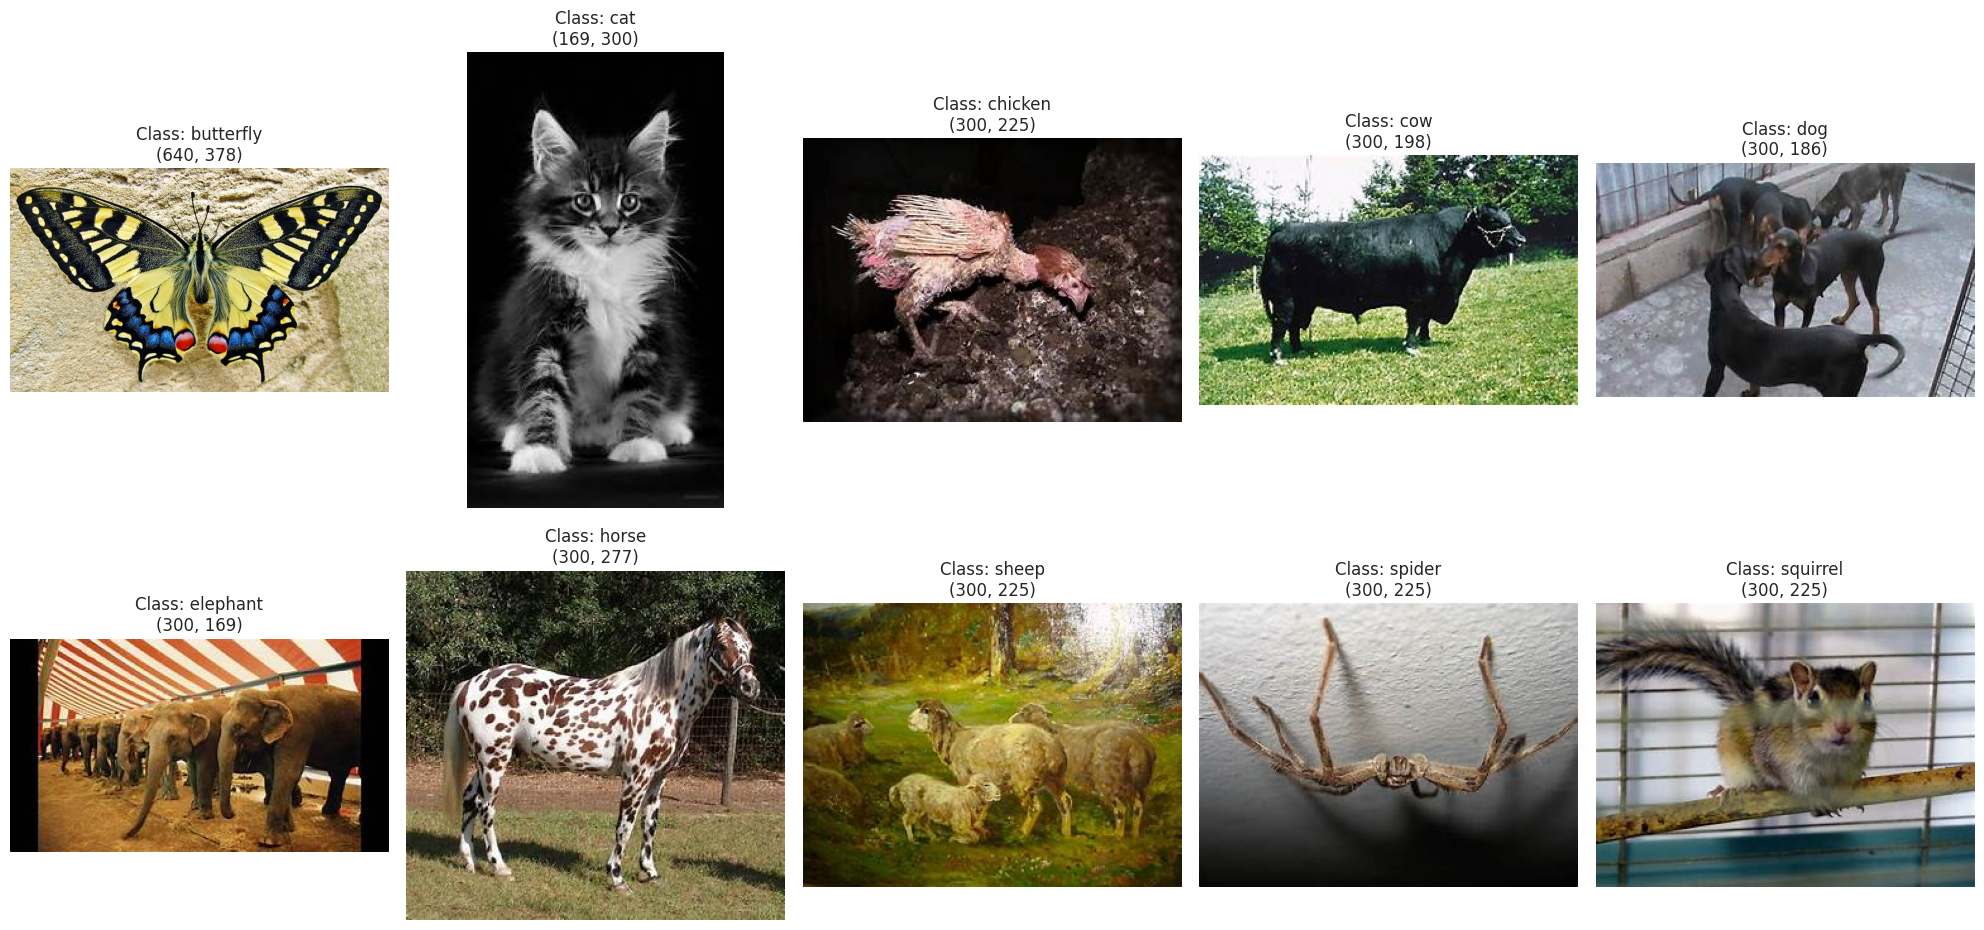

In [39]:
def get_dataset_stats(path):
    data = []
    for split in ['train', 'val', 'test']:
        p = Path(path) / split
        if not p.exists(): continue
        for cls_dir in p.iterdir():
            count = len(list(cls_dir.glob('*')))
            data.append({'Split': split, 'Class': cls_dir.name, 'Count': count})
    return pd.DataFrame(data)

stats_df = get_dataset_stats(PROCESSED_DIR)

plt.figure(figsize=(15, 6))
sns.barplot(data=stats_df, x='Class', y='Count', hue='Split', palette='viridis')
plt.title('Correct Class Distribution')
plt.xticks(rotation=45)
plt.show()

classes = sorted(stats_df[stats_df['Split'] == 'train']['Class'].unique())
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = PROCESSED_DIR / 'train' / cls
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(cls_path / img_name)
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {cls}\n{img.size}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [44]:
import json
import os
import random

def generate_ner_file(path, n=10000):
    animals = ['dog', 'cat', 'horse', 'spider', 'butterfly', 'chicken', 'sheep', 'cow', 'squirrel', 'elephant']
    templates = [
        "I see a {animal} in the field .",
        "This is not a {animal} .",
        "Look at that huge {animal} !",
        "My favorite animal is the {animal} .",
        "There is a {animal} running around .",
        "Is that a {animal} ?",
        "I have never seen a {animal} before .",
        "The {animal} is sleeping .",
        "Do not feed the {animal} .",
        "Wow , what a beautiful {animal} ."
    ]

    data = []
    for _ in range(n):
        animal = random.choice(animals)
        tokens = random.choice(templates).format(animal=animal).split()
        # 1 - это B-ANIMAL (согласно вашему мэппингу в модели)
        tags = [1 if t == animal else 0 for t in tokens]
        data.append({"tokens": tokens, "ner_tags": tags})

    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w') as f:
        # ИСПРАВЛЕНИЕ: сохраняем просто список data
        json.dump(data, f)

    print(f"Generated {n} samples in {path}")

NER_FILE = "/content/data/ner_dataset.json"
generate_ner_file(NER_FILE)

Generated 10000 samples in /content/data/ner_dataset.json


In [34]:
!pip install transformers datasets torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.2 MB/s eta 0:00:00


In [41]:
!python scripts/train_cv.py \
    --data /content/data/processed_images/train \
    --save_path /content/weights/best_cv_model.pth \
    --num_epochs 5

=== Start Computer Vision training pipeline ===
Dataset: /content/data/processed_images/train
Epochs: 5 | Batch: 32 | LR: 0.001
Found 10 classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Epoch 1/5, Loss: 0.3177
Epoch 2/5, Loss: 0.1306
Epoch 3/5, Loss: 0.1096
Epoch 4/5, Loss: 0.0932
Epoch 5/5, Loss: 0.0853
Model saved to /content/weights/best_cv_model.pth
=== Training completed successfully ===


In [47]:
import transformers
print(transformers.__version__)

5.0.0


In [52]:
!python scripts/train_ner.py \
    --data /content/data/ner_dataset.json \
    --save_dir /content/weights/best_ner_model

=== Starting NER training pipeline ===
Dataset: /content/data/ner_dataset.json
Epochs: 3 | Batch: 16 | LR: 2e-05
Loading base model distilbert-base-uncased
Loading weights: 100% 100/100 [00:00<00:00, 1233.10it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]
DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100% 10000/10000 [00:00<00

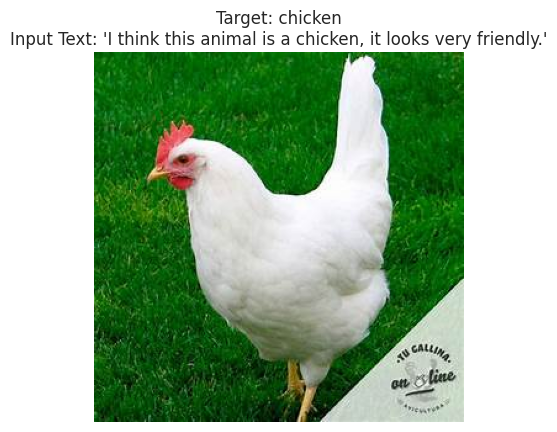

In [53]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

test_dir = Path("/content/data/processed_images/test")
random_class = random.choice([d.name for d in test_dir.iterdir() if d.is_dir()])
random_image = random.choice(list((test_dir / random_class).glob("*")))

sample_text = f"I think this animal is a {random_class}, it looks very friendly."

img = Image.open(random_image)
plt.imshow(img)
plt.title(f"Target: {random_class}\nInput Text: '{sample_text}'")
plt.axis('off')
plt.show()

TEST_IMAGE_PATH = str(random_image.absolute())
TEST_TEXT = sample_text

In [56]:
!echo "--- Running Computer Vision ---"
!python3 scripts/inference_cv.py --image "$TEST_IMAGE_PATH" --weights "weights/best_cv_model.pth"

!echo -e "\n--- Running Natural Language Processing ---"
!python3 scripts/inference_ner.py --text "$TEST_TEXT" --model_dir "weights/best_ner_model"

--- Running Computer Vision ---
=== Starting CV inference ===
Image: /content/data/processed_images/test/chicken/OIP-rL0V-1TP8VZTyupYhD0xXwHaHa.jpeg
Weights: weights/best_cv_model.pth

Found animal: chicken

--- Running Natural Language Processing ---
=== Starting NER inference ===
Text: 'I think this animal is a chicken, it looks very friendly.'
Model: weights/best_ner_model

Loading NER model from weights/best_ner_model
Loading weights: 100% 102/102 [00:00<00:00, 871.32it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]
Found animals: chicken, animal


In [55]:
from models.animal_cv_classifier import AnimalClassifier
from models.animal_ner_model import AnimalNerModel

cv_model = AnimalClassifier(weights_path="weights/best_cv_model.pth")
ner_model = AnimalNerModel(model_dir="weights/best_ner_model")

cv_res = cv_model.predict(TEST_IMAGE_PATH)

ner_res = ner_model.predict(TEST_TEXT)

match = cv_res in ner_res if ner_res else False

print(f"CV Prediction: {cv_res}")
print(f"NER Entities: {ner_res}")
print(f"VERDICT: {'MATCH! ✅' if match else 'MISMATCH! ❌'}")

Loading NER model from weights/best_ner_model


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

CV Prediction: chicken
NER Entities: ['animal', 'chicken']
VERDICT: MATCH! ✅


In [57]:
import random
from pathlib import Path
from models.animal_cv_classifier import AnimalClassifier
from models.animal_ner_model import AnimalNerModel
from pipeline import VerificationPipeline

cv_model = AnimalClassifier(weights_path="weights/best_cv_model.pth")
ner_model = AnimalNerModel(model_dir="weights/best_ner_model")
pipe = VerificationPipeline(cv_model, ner_model)

test_dir = Path("/content/data/processed_images/test")
random_class = random.choice([d.name for d in test_dir.iterdir() if d.is_dir()])
random_image = str(random.choice(list((test_dir / random_class).glob("*"))).absolute())

scenarios = [
    f"I see a {random_class} here .",    # Should be True
    f"This is not a {random_class} .",   # Should be False (negation)
    "There is a spider in the corner ."  # Should be False (wrong animal)
]

print(f"--- Pipeline Verification ---")
print(f"Image contains: {random_class.upper()}\n")

for text in scenarios:
    result = pipe.verify(random_image, text)
    print(f"Text: '{text}'")
    print(f"Verification: {'SUCCESS ✅' if result else 'FAILED ❌'}")
    print("-" * 30)

Loading NER model from weights/best_ner_model


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

--- Pipeline Verification ---
Image contains: CHICKEN

Text: 'I see a chicken here .'
Verification: SUCCESS ✅
------------------------------
Text: 'This is not a chicken .'
Verification: FAILED ❌
------------------------------
Text: 'There is a spider in the corner .'
Verification: FAILED ❌
------------------------------
